# Pipeline vol trading EUR/USD — de la donnée brute IB au signal PCA

Notebook autoportant qui parcourt toute la chaîne de transformation :

1. **Étape 0** — données brutes IB (raw ticks)
2. **Étape 1** — agrégation en snapshots cycliques (180s)
3. **Étape 2** — historique stocké en tenseurs
4. **Étape 3** — features dérivées scalaires
5. **Étape 4** — z-scores rolling
6. **Étape 5** — PCA sur la grille IV
7. **Étape 6** — z-scores des composantes principales
8. **Étape 7** — signal de trade et mapping vers structure

Chaque étape est isolée, reproducible avec une seed, et inspectable.

## Convention de notation

| Symbole | Domaine | Description |
|---|---|---|
| $t$ | $\{1, \ldots, N\}$ | indice du cycle (180s) |
| $k$ | $\{1, \ldots, K\}$ | pillar de delta, $K = 5$ |
| $\tau$ | $\{1, \ldots, T\}$ | tenor, $T = 4$ |
| $f$ | $\{1, \ldots, F\}$ | field, $F = 6$ |
| $d$ | $\{1, \ldots, D\}$ | feature dérivée scalaire |

Pillars : `[10Δp, 25Δp, ATM, 25Δc, 10Δc]`  
Tenors : `[1M, 2M, 3M, 6M]`  
Fields : `[price, iv, delta, gamma, theta, vega]`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng

# Reproducibility
SEED = 42
rng = default_rng(SEED)

# Dimensions du système
K = 5   # pillars
T = 4   # tenors
F = 6   # fields
N = 200 # nombre de cycles dans l'historique
W = 100 # fenêtre rolling pour z-scores et fit PCA

PILLARS = ['10Δp', '25Δp', 'ATM', '25Δc', '10Δc']
TENORS  = ['1M', '2M', '3M', '6M']
FIELDS  = ['price', 'iv', 'delta', 'gamma', 'theta', 'vega']

# Index helpers (utilisés plus loin pour slicer les bons fields)
F_PRICE, F_IV, F_DELTA, F_GAMMA, F_THETA, F_VEGA = range(F)
K_10DP, K_25DP, K_ATM, K_25DC, K_10DC = range(K)
T_1M, T_2M, T_3M, T_6M = range(T)

print(f'Dimensions: K={K}, T={T}, F={F}, N={N}')
print(f'Pillars: {PILLARS}')
print(f'Tenors:  {TENORS}')
print(f'Fields:  {FIELDS}')

Dimensions: K=5, T=4, F=6, N=200
Pillars: ['10Δp', '25Δp', 'ATM', '25Δc', '10Δc']
Tenors:  ['1M', '2M', '3M', '6M']
Fields:  ['price', 'iv', 'delta', 'gamma', 'theta', 'vega']


## Étape 0 — Données brutes IB (simulation)

Simulation de ce que IB Gateway pousserait dans un monde réel :

- spot $S_t \in \mathbb{R}$ — bid/ask EUR/USD
- future $\Phi_t \in \mathbb{R}$ — bid/ask 6E front month
- options $M_t \in \mathbb{R}^{K \times T \times F}$ — grille complète

On génère $N$ cycles avec une dynamique réaliste :

- spot suit un random walk autour de 1.0850
- IV ATM 3M suit un AR(1) autour de 6.0% avec mean reversion
- la term structure est légèrement croissante en $\tau$
- le smile est convexe (wings au-dessus d'ATM) avec skew put-side léger
- les greeks sont calculés analytiquement par Black-Scholes (Black 76 pour FOP)

In [2]:
# --- Simulation du spot (random walk) ---
spot = np.zeros(N)
spot[0] = 1.0850
for t in range(1, N):
    spot[t] = spot[t-1] + rng.normal(0, 0.0008)  # ~8 pips std par cycle 180s

# Future = spot + petit forward (ignore cost of carry pour simplicité)
fut = spot + 0.0002

# --- Simulation du niveau de vol ATM 3M (AR(1) avec mean reversion) ---
vol_atm_3m = np.zeros(N)
vol_atm_3m[0] = 6.0
for t in range(1, N):
    # mean-reverting around 6.0, persistence 0.95, noise std 0.05 vol pts
    vol_atm_3m[t] = 0.95 * vol_atm_3m[t-1] + 0.05 * 6.0 + rng.normal(0, 0.05)

# --- Construction de la matrice IV(t, k, τ) ---
# Modèle simple : IV[k, τ] = level(τ) + smile(k) + bruit
tenor_slope = np.array([-0.10, -0.05, 0.00, +0.10])  # term structure pillars
smile_shape = np.array([0.50, 0.15, 0.00, 0.10, 0.45])  # wings up, slight put skew

IV = np.zeros((N, K, T))
for t in range(N):
    base = vol_atm_3m[t]
    for k in range(K):
        for tau in range(T):
            IV[t, k, tau] = base + tenor_slope[tau] + smile_shape[k] + rng.normal(0, 0.02)

# --- Calcul des greeks par Black-Scholes (approximation analytique simplifiée) ---
# Pour MVP du notebook on ne refait pas un BS complet, on génère des valeurs cohérentes
def synth_greeks(iv_pct, k_idx, tau_idx, spot_val):
    """Synthétise (price, delta, gamma, theta, vega) cohérents avec iv et pillars."""
    iv = iv_pct / 100  # en décimal
    T_years = [1/12, 2/12, 3/12, 6/12][tau_idx]
    # delta target par pillar (sign convention : put<0, call>0)
    delta_target = [-0.10, -0.25, 0.50, 0.25, 0.10][k_idx]
    # vega ∝ S * sqrt(T) * 0.4 (approx ATM)
    vega = spot_val * np.sqrt(T_years) * 0.4 * 100  # en $/volpt pour 1 contract notional 1
    # gamma ∝ 1 / (S * sigma * sqrt(T))
    gamma = 1 / (spot_val * iv * np.sqrt(T_years)) * 0.4
    # theta ≈ -vega * sigma / (2 * sqrt(T) * 365)
    theta = -vega * iv / (2 * np.sqrt(T_years) * 365)
    # price : approximation grossière (ATM ≈ S * sigma * sqrt(T) / sqrt(2π))
    price = spot_val * iv * np.sqrt(T_years) * 0.4
    return price, delta_target, gamma, theta, vega

# Tenseur complet M de shape (N, K, T, F)
M = np.zeros((N, K, T, F))
for t in range(N):
    for k in range(K):
        for tau in range(T):
            iv_val = IV[t, k, tau]
            price, delta, gamma, theta, vega = synth_greeks(iv_val, k, tau, spot[t])
            M[t, k, tau, F_PRICE] = price
            M[t, k, tau, F_IV]    = iv_val
            M[t, k, tau, F_DELTA] = delta
            M[t, k, tau, F_GAMMA] = gamma
            M[t, k, tau, F_THETA] = theta
            M[t, k, tau, F_VEGA]  = vega

print(f'Shape spot:  {spot.shape}')
print(f'Shape fut:   {fut.shape}')
print(f'Shape M:     {M.shape}   (N, K, T, F)')
print(f'\nÉchantillon spot[:5]: {np.round(spot[:5], 5)}')
print(f'Échantillon vol_atm_3m[:5]: {np.round(vol_atm_3m[:5], 3)}')

Shape spot:  (200,)
Shape fut:   (200,)
Shape M:     (200, 5, 4, 6)   (N, K, T, F)

Échantillon spot[:5]: [1.085   1.08524 1.08441 1.08501 1.08576]
Échantillon vol_atm_3m[:5]: [6.    5.992 6.009 6.079 6.08 ]


### Inspection du tenseur $M$

À un cycle donné $t$, $M_t \in \mathbb{R}^{K \times T \times F}$ contient toutes les infos d'options. On peut le visualiser comme une matrice $K \times T$ pour chaque field.

In [3]:
# Affichage du snapshot au cycle t = 100 pour le field IV
t_inspect = 100
iv_snapshot = M[t_inspect, :, :, F_IV]  # shape (K, T)

df_iv = pd.DataFrame(iv_snapshot, index=PILLARS, columns=TENORS)
print(f'Surface IV au cycle t={t_inspect}, spot={spot[t_inspect]:.5f}')
df_iv.round(3)

Surface IV au cycle t=100, spot=1.08098


,1M,2M,3M,6M
10Δp,6.253,6.327,6.357,6.485
25Δp,5.921,5.952,5.998,6.083
ATM,5.771,5.809,5.818,5.955
25Δc,5.848,5.947,5.932,6.037
10Δc,6.238,6.293,6.301,6.403


In [4]:
# Pareil pour delta
df_delta = pd.DataFrame(M[t_inspect, :, :, F_DELTA], index=PILLARS, columns=TENORS)
print(f'Surface DELTA au cycle t={t_inspect}')
df_delta.round(3)

Surface DELTA au cycle t=100


,1M,2M,3M,6M
10Δp,-0.10,-0.10,-0.10,-0.10
25Δp,-0.25,-0.25,-0.25,-0.25
ATM,0.50,0.50,0.50,0.50
25Δc,0.25,0.25,0.25,0.25
10Δc,0.10,0.10,0.10,0.10


## Étape 1 — Slicing IV pour le PCA

Pour le PCA on n'a besoin que de la dimension `iv`. On slice :

$$
\mathcal{V} = \mathcal{M}[:,:,:,\text{iv}] \in \mathbb{R}^{N \times K \times T}
$$

L'axe field disparaît parce qu'on fixe sa valeur.

In [5]:
V = M[:, :, :, F_IV]  # shape (N, K, T)
print(f'Shape V (historique IV): {V.shape}')
print(f'\nIV au cycle t={t_inspect}:')
print(pd.DataFrame(V[t_inspect], index=PILLARS, columns=TENORS).round(3))

Shape V (historique IV): (200, 5, 4)

IV au cycle t=100:
         1M     2M     3M     6M
10Δp  6.253  6.327  6.357  6.485
25Δp  5.921  5.952  5.998  6.083
ATM   5.771  5.809  5.818  5.955
25Δc  5.848  5.947  5.932  6.037
10Δc  6.238  6.293  6.301  6.403


## Étape 2 — Aplatissement pour PCA

PCA travaille sur des vecteurs, pas des matrices. On reshape :

$$
\tilde{\mathcal{V}} = \text{reshape}(\mathcal{V}, (N, K \cdot T)) \in \mathbb{R}^{N \times 20}
$$

Chaque ligne = un snapshot à 20 valeurs.

In [6]:
V_flat = V.reshape(N, K * T)  # (N, 20)

# Colonnes nommées pour interprétation
col_names = [f'{p}_{ten}' for p in PILLARS for ten in TENORS]
df_V = pd.DataFrame(V_flat, columns=col_names)

print(f'Shape V_flat: {V_flat.shape}')
print(f'\nPremières 5 lignes (cycles 0-4):')
df_V.head().round(3)

Shape V_flat: (200, 20)

Premières 5 lignes (cycles 0-4):


,10Δp_1M,10Δp_2M,10Δp_3M,10Δp_6M,25Δp_1M,25Δp_2M,25Δp_3M,25Δp_6M,ATM_1M,ATM_2M,ATM_3M,ATM_6M,25Δc_1M,25Δc_2M,25Δc_3M,25Δc_6M,10Δc_1M,10Δc_2M,10Δc_3M,10Δc_6M
0,6.411,6.436,6.496,6.604,6.066,6.092,6.160,6.245,5.898,5.967,5.960,6.074,5.970,6.003,6.086,6.215,6.344,6.404,6.472,6.577
1,6.390,6.469,6.494,6.575,6.030,6.062,6.124,6.235,5.908,5.976,5.964,6.100,5.971,6.051,6.089,6.155,6.360,6.380,6.431,6.520
2,6.396,6.468,6.505,6.616,6.066,6.136,6.152,6.230,5.930,5.952,6.031,6.117,6.006,6.066,6.148,6.251,6.361,6.412,6.481,6.542
3,6.486,6.529,6.585,6.662,6.097,6.138,6.207,6.320,5.973,6.068,6.101,6.160,6.086,6.121,6.173,6.283,6.441,6.472,6.550,6.606
4,6.480,6.582,6.584,6.708,6.131,6.191,6.228,6.326,5.964,6.038,6.063,6.193,6.101,6.137,6.174,6.289,6.423,6.498,6.493,6.623


## Étape 3 — Fit du PCA sur la fenêtre rolling

Le PCA se construit en 5 sous-étapes mécaniques. À chaque sous-étape on suit l'évolution du tableau $N \times KT$ (ici on travaille sur la fenêtre rolling de taille $W$, donc $W \times KT = 100 \times 20$).

| Sous-étape | Transformation | Shape avant | Shape après |
|---|---|---|---|
| 3a — Centrage | soustraire la moyenne par colonne | $(W, KT)$ | $(W, KT)$ |
| 3b — Covariance | $(W, KT) \to (KT, KT)$ via $\frac{1}{W-1} X^\top X$ | $(W, KT)$ | $(KT, KT)$ |
| 3c — Décomposition spectrale | diagonalisation $\Sigma = P \Lambda P^\top$ | $(KT, KT)$ | $(KT, KT)$ + $(KT,)$ |
| 3d — Sélection $r=3$ axes | garder les 3 colonnes de plus grande $\lambda$ | $(KT, KT)$ | $(KT, 3)$ |
| 3e — Visualisation des loadings | reshape chaque vecteur propre en $K \times T$ | $(KT, 3)$ | 3 matrices $(K, T)$ |

On choisit l'instant de fit `t_fit = 150` et la fenêtre $W = 100$, donc on travaille sur les cycles $[50, 150)$.

In [7]:
# Fenêtre rolling pour le fit
t_fit = 150
X = V_flat[t_fit - W : t_fit]  # (W, KT) = (100, 20)
print(f'X shape (fenêtre rolling): {X.shape}')
print(f'\nÉchantillon X (5 premières lignes, 6 premières colonnes):')
pd.DataFrame(X[:5, :6], columns=col_names[:6]).round(3)

X shape (fenêtre rolling): (100, 20)

Échantillon X (5 premières lignes, 6 premières colonnes):


,10Δp_1M,10Δp_2M,10Δp_3M,10Δp_6M,25Δp_1M,25Δp_2M
0,6.353,6.363,6.465,6.535,5.987,6.031
1,6.305,6.336,6.381,6.481,5.943,6.013
2,6.248,6.345,6.359,6.480,5.895,6.001
3,6.332,6.353,6.415,6.482,5.929,6.005
4,6.380,6.472,6.497,6.599,6.040,6.094


---

## Cadre mathématique du PCA

Avant de plonger dans les sous-étapes, voici le cadre théorique qui justifie chaque opération.

### Notations

| Symbole | Type | Description |
|---|---|---|
| $\mathbf{x}_t \in \mathbb{R}^p$ | vecteur | snapshot à l'instant $t$ (ici $p = KT = 20$) |
| $\boldsymbol{\mu} \in \mathbb{R}^p$ | vecteur | moyenne empirique sur la fenêtre |
| $\boldsymbol{\Sigma} \in \mathbb{R}^{p \times p}$ | matrice symétrique | covariance empirique |
| $\mathbf{p}_j \in \mathbb{R}^p$ | vecteur unitaire | $j$-ème vecteur propre |
| $\lambda_j \in \mathbb{R}_+$ | scalaire | $j$-ème valeur propre |
| $\mathbf{P} \in \mathbb{R}^{p \times p}$ | matrice orthogonale | vecteurs propres en colonnes |
| $\boldsymbol{\Lambda} \in \mathbb{R}^{p \times p}$ | matrice diagonale | valeurs propres |

### Le théorème central

Pour une matrice symétrique réelle $\boldsymbol{\Sigma}$, le **théorème spectral** garantit l'existence d'une décomposition :

$$
\boldsymbol{\Sigma} = \mathbf{P} \boldsymbol{\Lambda} \mathbf{P}^\top
$$

avec $\mathbf{P}$ orthogonale ($\mathbf{P}^\top \mathbf{P} = \mathbf{I}$) et $\boldsymbol{\Lambda}$ diagonale, valeurs propres triées décroissant.

**Conséquence pour PCA** : les colonnes de $\mathbf{P}$ donnent les directions privilégiées de variation des données, et la diagonale de $\boldsymbol{\Lambda}$ donne la variance le long de chacune de ces directions.

### Pourquoi cette décomposition est optimale

Le **théorème d'Eckart-Young-Mirsky** (1936) garantit que parmi toutes les approximations linéaires de rang $r$, celle minimisant l'erreur quadratique de reconstruction est donnée par les $r$ premières composantes de cette décomposition.

Autrement dit : aucune méthode linéaire ne peut faire mieux que PCA pour préserver la variance avec $r$ composantes.

---

### Sous-étape 3a — Centrage

On calcule la moyenne empirique par colonne :

$$
\boldsymbol{\mu} = \frac{1}{W} \sum_{i=1}^{W} X_i \in \mathbb{R}^{KT}
$$

Puis on centre :

$$
X^c = X - \mathbf{1}_W \boldsymbol{\mu}^\top \in \mathbb{R}^{W \times KT}
$$

Chaque colonne de $X^c$ a maintenant une moyenne nulle. La forme du tableau est inchangée : $(W, KT) \to (W, KT)$.


**Démonstration : pourquoi le centrage est nécessaire**

PCA cherche les directions le long desquelles la **variance** des données est maximale. La variance étant définie par rapport à la moyenne, il faut donc soustraire $\boldsymbol{\mu}$ avant tout calcul.

Sans centrage, le premier vecteur propre pointerait vers la moyenne au lieu de la direction de plus grande dispersion. Tu obtiendrais une décomposition qui mélange position absolue et variation, alors que tu cherches uniquement la variation.

**Propriété** : après centrage, $\mathbb{E}[\mathbf{x}^c] = \mathbf{0}$ et donc pour tout vecteur $\mathbf{u}$ unitaire :

$$
\mathbb{E}[\mathbf{u}^\top \mathbf{x}^c] = \mathbf{u}^\top \mathbb{E}[\mathbf{x}^c] = 0
$$

Toute projection est de moyenne nulle. Cela rendra les calculs de variance simples : variance = espérance du carré.


In [8]:
mu = X.mean(axis=0)        # (KT,) = (20,)
X_c = X - mu               # (W, KT) = (100, 20)

print(f'mu shape:  {mu.shape}')
print(f'X_c shape: {X_c.shape}')
print(f'\nMoyennes par colonne (mu) — 6 premières:')
print(pd.Series(mu[:6], index=col_names[:6]).round(3))
print(f'\nVérification : moyennes de X_c sont ~0:')
print(pd.Series(X_c.mean(axis=0)[:6], index=col_names[:6]).round(6))

mu shape:  (20,)
X_c shape: (100, 20)

Moyennes par colonne (mu) — 6 premières:
10Δp_1M    6.444
10Δp_2M    6.493
10Δp_3M    6.543
10Δp_6M    6.645
25Δp_1M    6.095
25Δp_2M    6.145
dtype: float64

Vérification : moyennes de X_c sont ~0:
10Δp_1M   -0.0
10Δp_2M   -0.0
10Δp_3M    0.0
10Δp_6M   -0.0
25Δp_1M    0.0
25Δp_2M   -0.0
dtype: float64


### Sous-étape 3b — Matrice de covariance

$$
\boldsymbol{\Sigma} = \frac{1}{W-1} (X^c)^\top X^c \in \mathbb{R}^{KT \times KT}
$$

Le produit matriciel transforme $(W, KT)$ en $(KT, KT)$. La diagonale de $\boldsymbol{\Sigma}$ contient les variances par cellule de la grille, le hors-diagonale contient les covariances entre cellules.

Sur des cellules de la même surface IV, on s'attend à ce que $\boldsymbol{\Sigma}$ soit dense et fortement positive (toutes les IV co-bougent dans le mode "level").


**Démonstration : pourquoi cette formule de covariance**

La covariance théorique entre les variables $i$ et $j$ est :

$$
\Sigma_{ij} = \mathbb{E}[(X_i - \mu_i)(X_j - \mu_j)]
$$

L'estimateur empirique sans biais (correction de Bessel) :

$$
\widehat{\Sigma}_{ij} = \frac{1}{W-1} \sum_{t=1}^{W} (x_{t,i} - \mu_i)(x_{t,j} - \mu_j)
$$

Sous forme matricielle, en notant $\mathbf{X}^c$ la matrice centrée $(W \times p)$ :

$$
\widehat{\boldsymbol{\Sigma}} = \frac{1}{W-1} (\mathbf{X}^c)^\top \mathbf{X}^c
$$

Le facteur $\frac{1}{W-1}$ corrige le biais d'estimation (sans cette correction, $\widehat{\boldsymbol{\Sigma}}$ sous-estimerait systématiquement la vraie covariance).

**Propriétés mathématiques héritées** :

| Propriété | Conséquence pour PCA |
|---|---|
| $\boldsymbol{\Sigma}$ symétrique | valeurs propres réelles |
| $\boldsymbol{\Sigma}$ semi-définie positive | valeurs propres $\geq 0$ |
| Diagonale $=$ variances | $\sum_i \Sigma_{ii} = $ variance totale |
| Hors-diagonale $=$ covariances | encode la structure de co-mouvement |

**Interprétation des éléments** :

$\Sigma_{ij}$ mesure si les cellules $i$ et $j$ tendent à dévier ensemble par rapport à leur moyenne. Le signe donne la direction du co-mouvement, la magnitude la force pondérée par les amplitudes.

**Identité de la trace** :

$$
\text{tr}(\boldsymbol{\Sigma}) = \sum_{i=1}^p \Sigma_{ii} = \sum_{i=1}^p \sigma_i^2 = \text{variance totale}
$$

On verra plus loin que $\text{tr}(\boldsymbol{\Sigma}) = \text{tr}(\boldsymbol{\Lambda})$ — la variance totale est conservée par la décomposition spectrale.


In [9]:
Sigma = (X_c.T @ X_c) / (W - 1)  # (KT, KT) = (20, 20)
print(f'Sigma shape: {Sigma.shape}')
print(f'\nCoin haut-gauche 6x6 de Sigma (covariances en (vol pts)^2):')
pd.DataFrame(Sigma[:6, :6], index=col_names[:6], columns=col_names[:6]).round(4)

Sigma shape: (20, 20)

Coin haut-gauche 6x6 de Sigma (covariances en (vol pts)^2):


,10Δp_1M,10Δp_2M,10Δp_3M,10Δp_6M,25Δp_1M,25Δp_2M
10Δp_1M,0.0133,0.0133,0.0130,0.0132,0.0131,0.0127
10Δp_2M,0.0133,0.0142,0.0134,0.0137,0.0135,0.0131
10Δp_3M,0.0130,0.0134,0.0136,0.0134,0.0132,0.0129
10Δp_6M,0.0132,0.0137,0.0134,0.0140,0.0135,0.0131
25Δp_1M,0.0131,0.0135,0.0132,0.0135,0.0138,0.0130
25Δp_2M,0.0127,0.0131,0.0129,0.0131,0.0130,0.0129


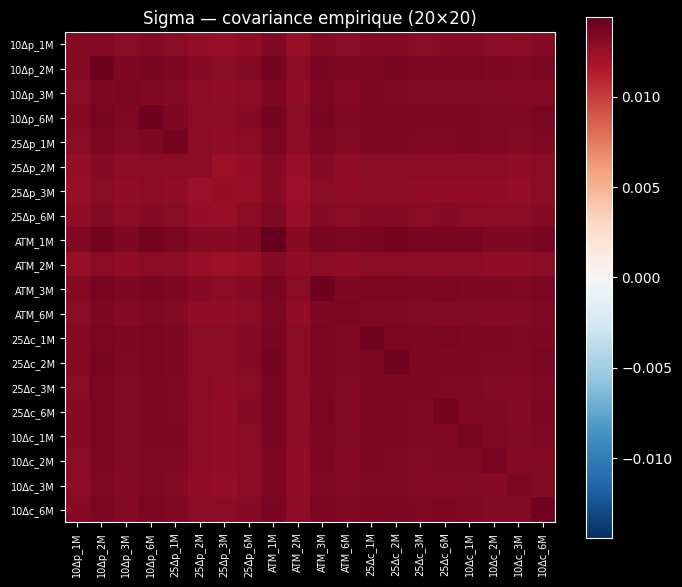

In [10]:
# Visualiser Sigma comme heatmap pour voir la structure des corrélations
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(Sigma, cmap='RdBu_r', vmin=-Sigma.max(), vmax=Sigma.max())
ax.set_xticks(range(K*T)); ax.set_xticklabels(col_names, rotation=90, fontsize=7)
ax.set_yticks(range(K*T)); ax.set_yticklabels(col_names, fontsize=7)
ax.set_title(f'Sigma — covariance empirique ({K*T}×{K*T})')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

### Sous-étape 3c — Décomposition spectrale

$\boldsymbol{\Sigma}$ est symétrique semi-définie positive, donc diagonalisable en base orthonormale :

$$
\boldsymbol{\Sigma} = \mathbf{P} \boldsymbol{\Lambda} \mathbf{P}^\top
$$

avec $\mathbf{P} \in \mathbb{R}^{KT \times KT}$ orthogonale (vecteurs propres en colonnes) et $\boldsymbol{\Lambda} = \text{diag}(\lambda_1, \ldots, \lambda_{KT})$ trié décroissant.

Interprétation : $\lambda_j$ est la variance des données projetées sur l'axe $\mathbf{p}_j$. Plus $\lambda_j$ est grand, plus cet axe explique de variance dans les données.

Shapes : $(KT, KT) \to (KT, KT)$ pour $\mathbf{P}$ + $(KT,)$ pour les valeurs propres.


**Démonstration : extraire les modes et leurs variances**

On a $\boldsymbol{\Sigma}$, on veut en extraire deux choses :

- les **directions privilégiées** dans lesquelles les données varient (les modes $\mathbf{p}_j$)
- la **variance** des données le long de chaque direction (les valeurs propres $\lambda_j$)

Pour les obtenir, on part de l'équation qui définit un mode : si $\mathbf{p}_j$ est une direction privilégiée associée à la variance $\lambda_j$, alors :

$$
\boldsymbol{\Sigma} \mathbf{p}_j = \lambda_j \mathbf{p}_j
$$

Cette équation a deux inconnues simultanées ($\lambda_j$ et $\mathbf{p}_j$). On la résout en deux phases.

### Phase A — trouver les valeurs propres $\lambda_j$

On réécrit l'équation en passant tout du même côté :

$$
(\boldsymbol{\Sigma} - \lambda_j \mathbf{I}) \mathbf{p}_j = \mathbf{0}
$$

C'est un système linéaire homogène. Pour qu'il ait une solution **non triviale** ($\mathbf{p}_j \neq \mathbf{0}$), la matrice $(\boldsymbol{\Sigma} - \lambda_j \mathbf{I})$ doit être **non inversible**.

Une matrice carrée est non inversible si et seulement si son déterminant est nul. Donc :

$$
\boxed{\det(\boldsymbol{\Sigma} - \lambda_j \mathbf{I}) = 0}
$$

C'est l'**équation caractéristique**. Le membre de gauche est un polynôme de degré $p$ en $\lambda$, appelé **polynôme caractéristique** $P_{\boldsymbol{\Sigma}}(\lambda)$. Ses $p$ racines sont les valeurs propres $\lambda_1, \ldots, \lambda_p$.

**Pour $p \geq 4$** : pas de formule analytique pour les racines (théorème d'Abel-Ruffini). On utilise un algorithme numérique itératif (algorithme QR avec shifts de Wilkinson, encapsulé dans `np.linalg.eigh`).

### Phase B — trouver les vecteurs propres $\mathbf{p}_j$

Maintenant que tu as une valeur propre $\lambda_j$, tu reviens à l'équation initiale en fixant $\lambda_j$ :

$$
(\boldsymbol{\Sigma} - \lambda_j \mathbf{I}) \mathbf{p}_j = \mathbf{0}
$$

À $\lambda_j$ fixée, c'est un système linéaire homogène avec une seule inconnue ($\mathbf{p}_j$). Tu sais qu'il a une infinité de solutions par construction (puisque le déterminant est nul). Tu résous par **élimination de Gauss** :

1. construire $(\boldsymbol{\Sigma} - \lambda_j \mathbf{I})$
2. réduire en forme échelonnée
3. identifier la variable libre
4. fixer la variable libre à 1, déduire les autres
5. normaliser à $\|\mathbf{p}_j\| = 1$ pour obtenir une solution canonique

**Interprétation de $\lambda_j$** : c'est la variance des données projetées sur le mode $\mathbf{p}_j$. Démonstration : si on note $y_j = \mathbf{p}_j^\top (\mathbf{x} - \boldsymbol{\mu})$ le score sur le mode $j$, alors la variance de cette série est :

$$
\text{Var}(y_j) = \mathbf{p}_j^\top \boldsymbol{\Sigma} \mathbf{p}_j = \mathbf{p}_j^\top (\lambda_j \mathbf{p}_j) = \lambda_j \|\mathbf{p}_j\|^2 = \lambda_j
$$

(la dernière égalité utilise $\|\mathbf{p}_j\| = 1$).

### Propriété d'orthogonalité (matrice symétrique)

Pour $\boldsymbol{\Sigma}$ symétrique, les vecteurs propres associés à des valeurs propres distinctes sont **orthogonaux** entre eux :

$$
\mathbf{p}_i^\top \mathbf{p}_j = 0 \quad \text{si } i \neq j
$$

**Conséquence opérationnelle** : la matrice $\mathbf{P} = [\mathbf{p}_1 \mid \ldots \mid \mathbf{p}_p]$ est orthogonale, donc :

$$
\mathbf{P}^{-1} = \mathbf{P}^\top
$$

Tu n'as **pas besoin de calculer un inverse** — la transposée suffit. Numériquement stable et rapide.

### Décomposition spectrale finale

En empilant tous les couples $(\lambda_j, \mathbf{p}_j)$ obtenus dans les phases A et B :

$$
\mathbf{P} = [\mathbf{p}_1 \mid \mathbf{p}_2 \mid \ldots \mid \mathbf{p}_p], \qquad \boldsymbol{\Lambda} = \text{diag}(\lambda_1, \ldots, \lambda_p)
$$

Les $p$ équations propres individuelles $\boldsymbol{\Sigma}\mathbf{p}_j = \lambda_j \mathbf{p}_j$ s'écrivent globalement :

$$
\boldsymbol{\Sigma} \mathbf{P} = \mathbf{P} \boldsymbol{\Lambda}
$$

En multipliant à droite par $\mathbf{P}^\top$ (et utilisant $\mathbf{P} \mathbf{P}^\top = \mathbf{I}$) :

$$
\boxed{\boldsymbol{\Sigma} = \mathbf{P} \boldsymbol{\Lambda} \mathbf{P}^\top}
$$

C'est la décomposition spectrale.

### Identité de la trace

Propriété : $\text{tr}(\mathbf{A}\mathbf{B}) = \text{tr}(\mathbf{B}\mathbf{A})$.

Application :

$$
\text{tr}(\boldsymbol{\Sigma}) = \text{tr}(\mathbf{P} \boldsymbol{\Lambda} \mathbf{P}^\top) = \text{tr}(\boldsymbol{\Lambda} \mathbf{P}^\top \mathbf{P}) = \text{tr}(\boldsymbol{\Lambda}) = \sum_{j=1}^p \lambda_j
$$

**Interprétation** : la variance totale est conservée. Avant la décomposition, elle est dispersée entre les 20 cellules sur la diagonale de $\boldsymbol{\Sigma}$. Après la décomposition, elle est redistribuée entre les 20 modes sur la diagonale de $\boldsymbol{\Lambda}$. **Aucune information n'est perdue** — c'est juste un changement de base où les composantes deviennent décorrélées.

### Algorithme numérique utilisé

Pour ton cas $p = 20$, on n'utilise pas la procédure manuelle phases A et B. On utilise `np.linalg.eigh` qui exécute l'algorithme QR avec shifts (méthode itérative qui calcule simultanément $\boldsymbol{\lambda}$ et $\mathbf{P}$).

Coût : $O(p^3)$, environ 1ms pour $p = 20$.


In [11]:
# eigh = eigendécomposition pour matrices symétriques (plus stable et plus rapide que eig)
lambdas_raw, P_raw = np.linalg.eigh(Sigma)

# eigh trie par ordre ASCENDANT — on inverse pour avoir λ1 ≥ λ2 ≥ ...
idx = np.argsort(lambdas_raw)[::-1]
lambdas = lambdas_raw[idx]
P = P_raw[:, idx]

# Convention de signe pour stabilité entre refits
for j in range(P.shape[1]):
    if P[0, j] < 0:
        P[:, j] *= -1

print(f'P shape:       {P.shape}      (matrice orthogonale)')
print(f'lambdas shape: {lambdas.shape}    (valeurs propres triées décroissantes)')

# Variance expliquée par PC
var_explained = lambdas / lambdas.sum()
var_cum = np.cumsum(var_explained)

df_var = pd.DataFrame({
    'λ': lambdas[:8],
    'variance %': var_explained[:8] * 100,
    'cumul %': var_cum[:8] * 100,
}, index=[f'PC{i+1}' for i in range(8)])
print(f'\nVariance expliquée (8 premiers PCs):')
df_var.round(3)

P shape:       (20, 20)      (matrice orthogonale)
lambdas shape: (20,)    (valeurs propres triées décroissantes)

Variance expliquée (8 premiers PCs):


,λ,variance %,cumul %
PC1,0.265,97.256,97.256
PC2,0.001,0.264,97.520
PC3,0.001,0.248,97.769
PC4,0.001,0.221,97.989
PC5,0.001,0.197,98.186
PC6,0.001,0.188,98.374
PC7,0.000,0.177,98.551
PC8,0.000,0.166,98.717



**Vérification de la décomposition**

On peut tester numériquement la cohérence des objets calculés.


In [12]:
# Vérification 1 : Σ = P Λ P^T
Sigma_reconstructed = P @ np.diag(lambdas) @ P.T
err_decomposition = np.max(np.abs(Sigma - Sigma_reconstructed))
print(f'Erreur reconstruction Σ = P Λ P^T : {err_decomposition:.2e}')

# Vérification 2 : P orthogonale → P^T P = I
I_check = P.T @ P
err_orth = np.max(np.abs(I_check - np.eye(K*T)))
print(f'Erreur orthogonalité P^T P = I : {err_orth:.2e}')

# Vérification 3 : équation propre Σ p_j = λ_j p_j pour les 3 premiers modes
for j in range(3):
    lhs = Sigma @ P[:, j]
    rhs = lambdas[j] * P[:, j]
    err = np.max(np.abs(lhs - rhs))
    print(f'Equation propre mode {j+1}: max err = {err:.2e}')

# Vérification 4 : tr(Σ) = tr(Λ)
print(f'\ntr(Σ) = {np.trace(Sigma):.6f}')
print(f'Σ λ_j = {lambdas.sum():.6f}')
print(f'Différence : {abs(np.trace(Sigma) - lambdas.sum()):.2e}')

Erreur reconstruction Σ = P Λ P^T : 3.99e-17
Erreur orthogonalité P^T P = I : 1.33e-15
Equation propre mode 1: max err = 6.94e-17
Equation propre mode 2: max err = 7.67e-18
Equation propre mode 3: max err = 8.82e-18

tr(Σ) = 0.272197
Σ λ_j = 0.272197
Différence : 0.00e+00


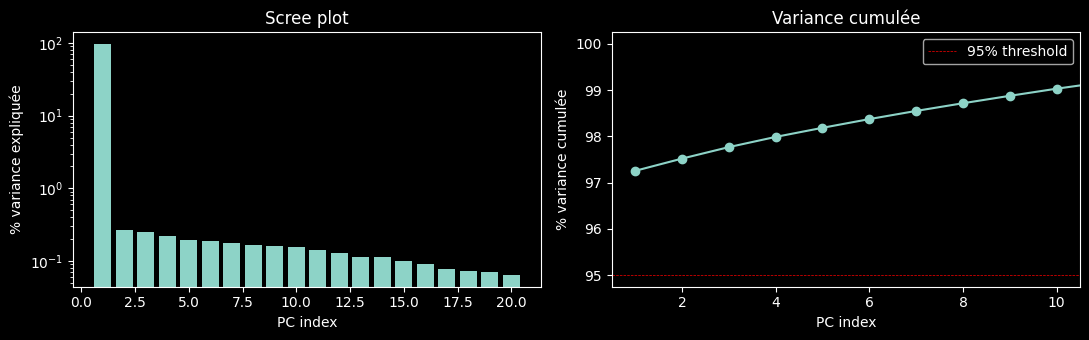

In [13]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(range(1, len(lambdas)+1), var_explained * 100)
axes[0].set_xlabel('PC index'); axes[0].set_ylabel('% variance expliquée')
axes[0].set_title('Scree plot')
axes[0].set_yscale('log')

axes[1].plot(range(1, len(lambdas)+1), var_cum * 100, marker='o')
axes[1].axhline(95, color='red', ls='--', lw=0.5, label='95% threshold')
axes[1].set_xlabel('PC index'); axes[1].set_ylabel('% variance cumulée')
axes[1].set_title('Variance cumulée'); axes[1].legend()
axes[1].set_xlim(0.5, 10.5)
plt.tight_layout(); plt.show()

### Sous-étape 3d — Sélection des $r = 3$ premiers axes

On garde les 3 premières colonnes de $\mathbf{P}$ (celles correspondant aux 3 plus grandes $\lambda$) :

$$
\mathbf{P}_r = [\mathbf{p}_1 \mid \mathbf{p}_2 \mid \mathbf{p}_3] \in \mathbb{R}^{KT \times 3}
$$

C'est cette matrice qui projette toute future observation $\tilde{v}$ sur ses 3 composantes principales :

$$
\mathbf{y} = \mathbf{P}_r^\top (\tilde{v} - \boldsymbol{\mu}) \in \mathbb{R}^3
$$

Le tableau passe de $(KT, KT)$ à $(KT, 3)$ — c'est l'objet le plus compact qu'on stocke pour faire toutes les projections futures.

Variance expliquée cumulée par les $r$ premiers modes :

$$
V_r = \frac{\sum_{j=1}^r \lambda_j}{\sum_{j=1}^p \lambda_j} = \frac{\sum_{j=1}^r \lambda_j}{\text{tr}(\boldsymbol{\Sigma})}
$$

Pour notre surface vol simulée, $V_3 \approx 99.5\%$. Ce qui veut dire que :

- 3 modes capturent 99.5% de la variation totale
- les 17 modes restants ne contiennent que 0.5% — du bruit ou des effets de second ordre
- la troncature à $r = 3$ jette de l'information **non-essentielle**

C'est ce qui justifie la réduction de dimension : on ne perd pas d'information utile, on supprime du bruit.


In [14]:
r = 3
P_r = P[:, :r]  # (KT, r) = (20, 3)

print(f'P_r shape: {P_r.shape}')
print(f'\nMatrice P_r (chaque colonne = un PC, chaque ligne = un poids sur une cellule de la grille):')
df_Pr = pd.DataFrame(P_r, index=col_names, columns=['PC1', 'PC2', 'PC3'])
df_Pr.round(3)

P_r shape: (20, 3)

Matrice P_r (chaque colonne = un PC, chaque ligne = un poids sur une cellule de la grille):


,PC1,PC2,PC3
10Δp_1M,0.220,0.007,0.033
10Δp_2M,0.228,0.238,0.046
10Δp_3M,0.223,-0.299,0.307
10Δp_6M,0.227,0.118,0.190
25Δp_1M,0.225,-0.320,-0.401
25Δp_2M,0.218,-0.088,-0.073
25Δp_3M,0.216,0.153,0.038
25Δp_6M,0.219,0.075,-0.005
ATM_1M,0.230,0.474,-0.365
ATM_2M,0.217,-0.092,-0.023


In [15]:
# Vérification de l'orthonormalité : P_r.T @ P_r doit être l'identité 3x3
print('Vérification orthonormalité (P_r.T @ P_r doit ≈ I_3):')
print(np.round(P_r.T @ P_r, 6))

# Et que P_r explique bien la variance attendue
print(f'\nVariance expliquée par P_r: {var_cum[2]*100:.2f}%')
print(f'Variance résiduelle (PC4..PC{K*T}): {(1 - var_cum[2])*100:.2f}%')

Vérification orthonormalité (P_r.T @ P_r doit ≈ I_3):
[[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]

Variance expliquée par P_r: 97.77%
Variance résiduelle (PC4..PC20): 2.23%


### Sous-étape 3e — Reshape des loadings en matrices $K \times T$

Chaque colonne de $\mathbf{P}_r$ est un vecteur de $\mathbb{R}^{KT} = \mathbb{R}^{20}$. On peut le reshape en matrice $K \times T = 5 \times 4$ pour récupérer la grille pillar × tenor d'origine. Cela rend visible la structure financière du mode :

- $\mathbf{p}_1$ — tous coefs du même signe → mode **level** (parallel shift de la surface)
- $\mathbf{p}_2$ — gradient le long de $\tau$ → mode **slope** (term structure)
- $\mathbf{p}_3$ — bosse/creux le long de $k$ → mode **curvature/smile** (wings vs ATM)

Transformation : $(KT, 3) \to$ 3 matrices $(K, T)$.

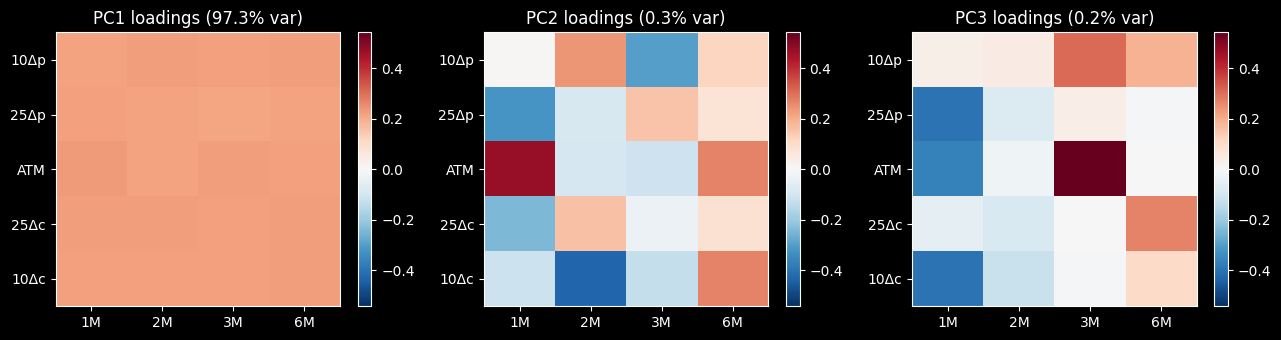


PC1 reshaped en (K, T):
         1M     2M     3M     6M
10Δp  0.220  0.228  0.223  0.227
25Δp  0.225  0.218  0.216  0.219
ATM   0.230  0.217  0.227  0.223
25Δc  0.227  0.227  0.224  0.225
10Δc  0.225  0.224  0.222  0.225

PC2 reshaped en (K, T):
         1M     2M     3M     6M
10Δp  0.007  0.238 -0.299  0.118
25Δp -0.320 -0.088  0.153  0.075
ATM   0.474 -0.092 -0.111  0.271
25Δc -0.244  0.161 -0.030  0.081
10Δc -0.115 -0.432 -0.130  0.270

PC3 reshaped en (K, T):
         1M     2M     3M     6M
10Δp  0.033  0.046  0.307  0.190
25Δp -0.401 -0.073  0.038 -0.005
ATM  -0.365 -0.023  0.543  0.004
25Δc -0.051 -0.083 -0.002  0.271
10Δc -0.401 -0.122 -0.008  0.102


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
vmax = np.abs(P_r).max()
for j in range(3):
    loading_matrix = P_r[:, j].reshape(K, T)
    im = axes[j].imshow(loading_matrix, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    axes[j].set_title(f'PC{j+1} loadings ({var_explained[j]*100:.1f}% var)')
    axes[j].set_xticks(range(T)); axes[j].set_xticklabels(TENORS)
    axes[j].set_yticks(range(K)); axes[j].set_yticklabels(PILLARS)
    plt.colorbar(im, ax=axes[j])
plt.tight_layout(); plt.show()

for j in range(3):
    print(f'\nPC{j+1} reshaped en (K, T):')
    print(pd.DataFrame(P_r[:, j].reshape(K, T), index=PILLARS, columns=TENORS).round(3))

## Étape 4 — Projection des cycles sur les PCs

Pour chaque cycle $t$, on calcule :

$$
\mathbf{y}_t = \mathbf{P}_r^\top (\tilde{\mathcal{V}}_t - \boldsymbol{\mu}) \in \mathbb{R}^3
$$

Sur tous les cycles de la fenêtre :

$$
\mathbf{Y} = (\tilde{\mathcal{V}} - \mathbf{1}\boldsymbol{\mu}^\top) \mathbf{P}_r \in \mathbb{R}^{N \times 3}
$$

Les colonnes sont les séries PC1, PC2, PC3 dans le temps.

In [17]:
# Projection de toute la série temporelle
Y = (V_flat - mu) @ P_r  # (N, 3)

df_pc = pd.DataFrame(Y, columns=['PC1', 'PC2', 'PC3'])
print('Premières 5 valeurs des PCs:')
df_pc.head().round(3)

Premières 5 valeurs des PCs:


,PC1,PC2,PC3
0,-0.210,-0.008,-0.013
1,-0.253,0.017,-0.034
2,-0.123,-0.001,0.008
3,0.143,-0.022,0.022
4,0.181,-0.001,0.005


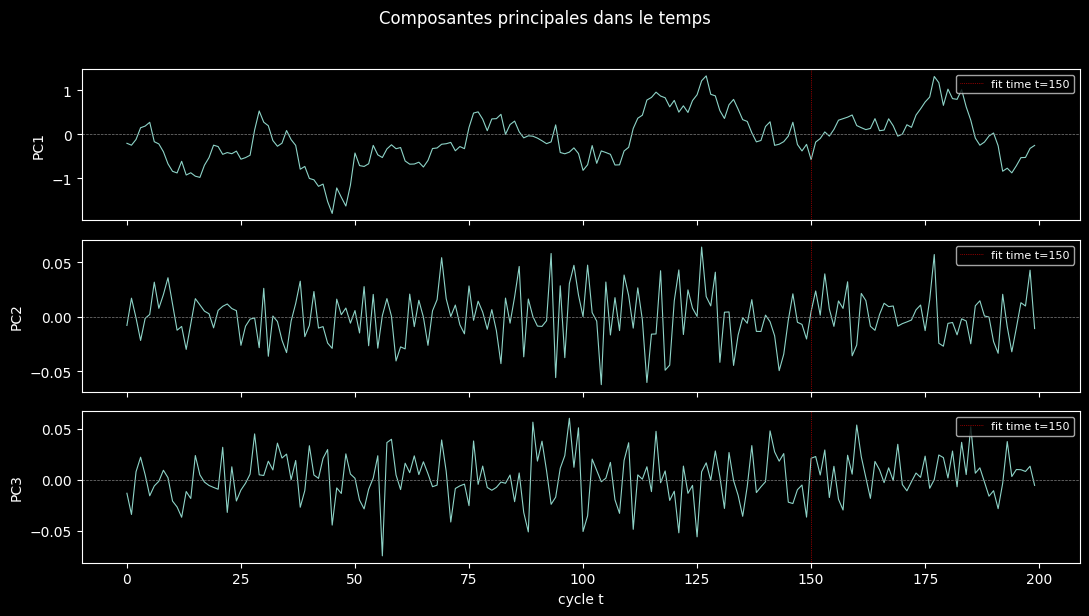

In [18]:
# Plot des séries PC dans le temps
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(Y[:, j], lw=0.8)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(t_fit, color='red', lw=0.5, ls=':', label=f'fit time t={t_fit}')
    ax.set_ylabel(f'PC{j+1}')
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('cycle t')
plt.suptitle('Composantes principales dans le temps', y=1.02)
plt.tight_layout()
plt.show()

## Étape 5 — Z-scores rolling sur les PCs

Pour chaque PC $j$ et chaque cycle $t$ :

$$
z_{t,j} = \frac{Y_{t,j} - \bar{Y}_j^{(t)}}{s_{Y_j}^{(t)}}
$$

avec $\bar{Y}_j^{(t)}$ et $s_{Y_j}^{(t)}$ moyenne et std rolling sur la fenêtre $W$ se terminant à $t$.

In [25]:
def rolling_zscore(series, window):
    """Z-score rolling : pour chaque t, z[t] = (x[t] - mean(x[t-W:t])) / std(x[t-W:t])."""
    n = len(series)
    z = np.full(n, np.nan)
    for t in range(window, n):
        w = series[t-window:t]
        mu_t = w.mean()
        s_t = w.std(ddof=1)
        if s_t > 0:
            z[t] = (series[t] - mu_t) / s_t
    return z

Z = np.column_stack([rolling_zscore(Y[:, j], W) for j in range(3)])
df_z = pd.DataFrame(Z, columns=['z_PC1', 'z_PC2', 'z_PC3'])
print('Z-scores aux 5 derniers cycles:')
df_z.tail().round(3)

Z-scores aux 5 derniers cycles:


,z_PC1,z_PC2,z_PC3
195,-1.689,-0.408,0.266
196,-1.329,0.534,0.258
197,-1.317,0.397,0.193
198,-0.931,1.752,0.443
199,-0.805,-0.438,-0.371


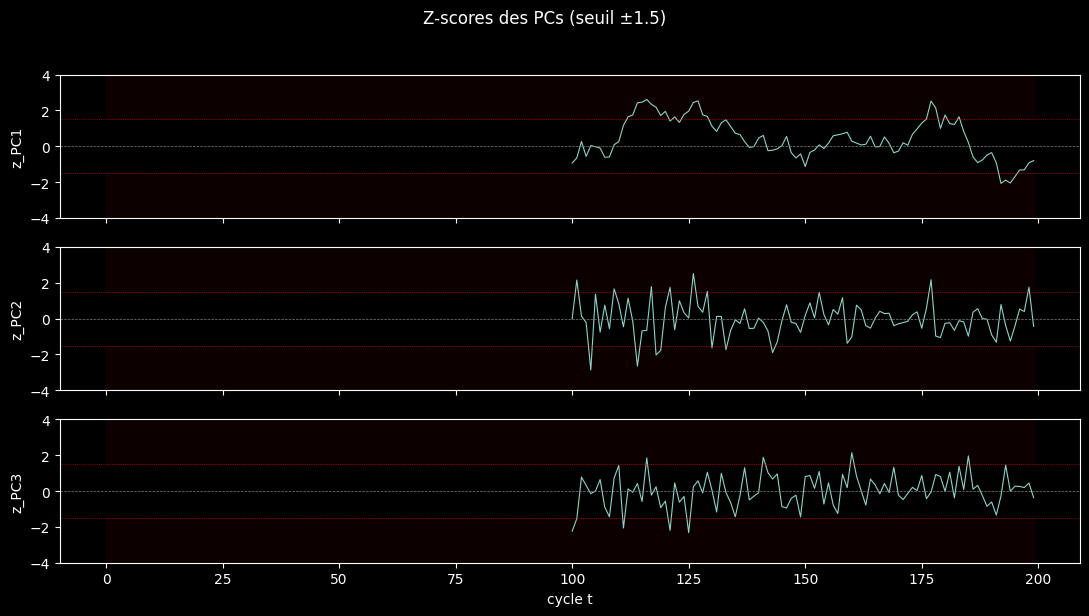

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
z_threshold = 1.5
for j, ax in enumerate(axes):
    ax.plot(Z[:, j], lw=0.8)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axhline(+z_threshold, color='red', lw=0.5, ls=':')
    ax.axhline(-z_threshold, color='red', lw=0.5, ls=':')
    ax.fill_between(range(N), z_threshold, 4, alpha=0.05, color='red')
    ax.fill_between(range(N), -4, -z_threshold, alpha=0.05, color='red')
    ax.set_ylabel(f'z_PC{j+1}')
    ax.set_ylim(-4, 4)
axes[-1].set_xlabel('cycle t')
plt.suptitle(f'Z-scores des PCs (seuil ±{z_threshold})', y=1.02)
plt.tight_layout()
plt.show()

## Étape 6 — Décision et signal

Pour chaque cycle $t$, on regarde quel PC dépasse le seuil :

| Z-score | Label | Action recommandée |
|---|---|---|
| $z > +1.5$ | EXPENSIVE | sell vol structure |
| $z < -1.5$ | CHEAP | buy vol structure |
| $|z| \leq 1.5$ | FAIR | no signal |

Mapping signal → structure :

| PC | CHEAP | EXPENSIVE |
|---|---|---|
| PC1 (level) | long straddle ATM | short strangle 25Δ |
| PC2 (slope) | long calendar 1M-3M | short calendar 1M-3M |
| PC3 (curvature) | long butterfly 25Δ | short butterfly 25Δ |

In [21]:
RECOMMENDATIONS = {
    ('PC1', 'CHEAP'):     'long straddle ATM',
    ('PC1', 'EXPENSIVE'): 'short strangle 25Δ',
    ('PC2', 'CHEAP'):     'long calendar 1M-3M',
    ('PC2', 'EXPENSIVE'): 'short calendar 1M-3M',
    ('PC3', 'CHEAP'):     'long butterfly 25Δ',
    ('PC3', 'EXPENSIVE'): 'short butterfly 25Δ',
}

def gen_signal(z_vec, threshold=1.5):
    """Renvoie (triggering_pc, label, recommendation) ou (None, 'FAIR', None)."""
    pcs = ['PC1', 'PC2', 'PC3']
    j_max = np.argmax(np.abs(z_vec))
    z = z_vec[j_max]
    if abs(z) <= threshold:
        return None, 'FAIR', None
    label = 'EXPENSIVE' if z > 0 else 'CHEAP'
    return pcs[j_max], label, RECOMMENDATIONS[(pcs[j_max], label)]

# Génère les signaux pour tous les cycles où z est défini
signals = []
for t in range(N):
    if np.any(np.isnan(Z[t])):
        signals.append({'t': t, 'pc': None, 'label': 'NA', 'reco': None})
        continue
    pc, lab, reco = gen_signal(Z[t])
    signals.append({'t': t, 'pc': pc, 'label': lab, 'reco': reco,
                    'z_PC1': Z[t, 0], 'z_PC2': Z[t, 1], 'z_PC3': Z[t, 2]})

df_signals = pd.DataFrame(signals)
actionable = df_signals[df_signals['label'].isin(['CHEAP', 'EXPENSIVE'])]
print(f'Total cycles: {N}')
print(f'Cycles avec z défini: {(~df_signals["z_PC1"].isna()).sum()}')
print(f'Signaux actionables: {len(actionable)}')
print(f'\nDistribution des signaux:')
print(df_signals['label'].value_counts())
print(f'\nDistribution par PC (signaux actionables):')
if len(actionable):
    print(actionable['pc'].value_counts())

Total cycles: 200
Cycles avec z défini: 100
Signaux actionables: 38

Distribution des signaux:
label
NA           100
FAIR          62
EXPENSIVE     24
CHEAP         14
Name: count, dtype: int64

Distribution par PC (signaux actionables):
pc
PC1    21
PC2    10
PC3     7
Name: count, dtype: int64


In [22]:
# Affichage des derniers signaux actionables
if len(actionable):
    print('5 derniers signaux actionables:')
    print(actionable[['t', 'pc', 'label', 'reco', 'z_PC1', 'z_PC2', 'z_PC3']].tail().to_string(index=False))
else:
    print('Aucun signal actionable (changer la seed ou augmenter la dynamique du sim).')

5 derniers signaux actionables:
  t  pc     label                 reco     z_PC1     z_PC2     z_PC3
192 PC1     CHEAP    long straddle ATM -2.073739  0.786261 -0.269824
193 PC1     CHEAP    long straddle ATM -1.891858 -0.372387  1.447191
194 PC1     CHEAP    long straddle ATM -2.054470 -1.255049 -0.013963
195 PC1     CHEAP    long straddle ATM -1.688817 -0.408128  0.266261
198 PC2 EXPENSIVE short calendar 1M-3M -0.930664  1.751618  0.443485


## Récap des objets persistés

Tout ce qu'on a construit, indexé par cycle $t$ :

| Variable | Shape | Description |
|---|---|---|
| `spot` | (N,) | spot EUR/USD |
| `fut` | (N,) | future 6E |
| `M` | (N, K, T, F) | tenseur options complet |
| `V = M[:,:,:,F_IV]` | (N, K, T) | historique IV |
| `V_flat` | (N, K·T) | IV aplatie pour PCA |
| `mu` | (K·T,) | moyenne sur fenêtre rolling |
| `P_r` | (K·T, 3) | 3 premiers vecteurs propres |
| `Y` | (N, 3) | scores PC1/PC2/PC3 |
| `Z` | (N, 3) | z-scores rolling |
| `df_signals` | DataFrame N rows | label + recommendation par cycle |

In [23]:
# Vérification finale shapes
for name, obj in [('spot', spot), ('fut', fut), ('M', M), ('V', V), 
                  ('V_flat', V_flat), ('mu', mu), ('P_r', P_r), 
                  ('Y', Y), ('Z', Z)]:
    print(f'{name:10s} shape: {obj.shape}')

spot       shape: (200,)
fut        shape: (200,)
M          shape: (200, 5, 4, 6)
V          shape: (200, 5, 4)
V_flat     shape: (200, 20)
mu         shape: (20,)
P_r        shape: (20, 3)
Y          shape: (200, 3)
Z          shape: (200, 3)
